In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path
import pandas as pd
from transformers import AutoTokenizer
from transformers import BertModel
import sys
import torch

sys.path.append(str(Path("..")))

from utils.ai_human_predictor import AiHumanPredictor

device = "cuda"

In [3]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
encoder = BertModel.from_pretrained("bert-base-uncased")

predictor = AiHumanPredictor(tokenizer, encoder, "../models/sgd_classifier.pkl", device)
predictor.load_head()

Head model loaded from ..\models\sgd_classifier.pkl successfully


c:\Users\Pawel\anaconda3\envs\human-vs-ai\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SGDClassifier from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
model_dir = "models"


model_files = [file for file in Path.iterdir(Path(f"../{model_dir}")) if not Path.is_dir(file)]

model_dict = {}
for file in model_files:
    with open(file, "rb") as f:
        model_dict[file] = pickle.load(f)
model_dict

{WindowsPath('../models/decision_tree.pkl'): DecisionTreeClassifier(max_depth=50, max_features='sqrt', min_samples_leaf=100,
                        min_samples_split=200, random_state=42),
 WindowsPath('../models/linear_svc.pkl'): LinearSVC(max_iter=10000, random_state=42),
 WindowsPath('../models/logistic_regression.pkl'): LogisticRegressionCV(cv=5, max_iter=1000, n_jobs=-1, random_state=42),
 WindowsPath('../models/random_forest.pkl'): RandomForestClassifier(n_jobs=-1, random_state=42),
 WindowsPath('../models/sgd.pkl'): SGDClassifier(random_state=42),
 WindowsPath('../models/sgd_classifier.pkl'): SGDClassifier(random_state=42)}

In [5]:
def get_feature_importances(model):
    if hasattr(model, "coef_"):
        return model.coef_.ravel()
    elif hasattr(model, "feature_importances_"):
        return model.feature_importances_


df = (
    pd.DataFrame(
        {
            model_path.stem: get_feature_importances(model)
            for model_path, model in model_dict.items()
        }
    )
    .reset_index(drop=False)
    .rename(columns={"index": "feature_num"})
)
df.head()

,feature_num,decision_tree,linear_svc,logistic_regression,random_forest,sgd,sgd_classifier
0,0,0.000304,-0.101602,0.107380,0.000918,0.115872,2.476898
1,1,0.000011,0.080373,0.538480,0.000590,0.523884,3.229175
2,2,0.004916,-0.065904,-0.370628,0.031070,-0.994019,0.584077
3,3,0.000722,0.294013,0.818736,0.001398,0.840791,-5.520673
4,4,0.000863,-0.208797,-0.612184,0.000699,-0.753135,0.212451


## Model Correlation Analysis

**Two complementary analyses:**

### 1. Feature-Level Correlation
- Correlates model **weights/importances** across 768 BERT dimensions
- **Question:** "Do models rely on the same embedding dimensions?"

### 2. Prediction-Level Correlation
- Correlates actual **predictions** across 97K test samples
- **Question:** "Do models agree on which specific texts are AI/Human?"
- Split by true label: Agreement on AI samples vs Human samples

**Key insight:** Models can have similar feature weights but make different predictions, or vice versa!


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Overall feature correlation
print("=== Feature-Level Correlation (768 dimensions) ===")
feature_corr = df.drop(columns="feature_num").corr(method="spearman")
feature_corr

=== Feature-Level Correlation (768 dimensions) ===


,decision_tree,linear_svc,logistic_regression,random_forest,sgd,sgd_classifier
decision_tree,1.000000,0.005361,0.009749,0.555594,0.031961,0.015814
linear_svc,0.005361,1.000000,0.964095,0.011707,0.864587,0.056849
logistic_regression,0.009749,0.964095,1.000000,0.002575,0.947196,0.071039
random_forest,0.555594,0.011707,0.002575,1.000000,0.012931,-0.016732
sgd,0.031961,0.864587,0.947196,0.012931,1.000000,0.094586
sgd_classifier,0.015814,0.056849,0.071039,-0.016732,0.094586,1.000000


In [7]:
# Option 2: Prediction-level correlation (sample-by-sample agreement)
from datasets import load_from_disk

print("\n=== Loading test data ===")
dataset = load_from_disk("../data/processed/AI_Human/encoded/bert_bert")
X_test = np.array(dataset['test']['embeddings'])
y_test = np.array(dataset['test']['labels'])

print(f"Test samples: {len(y_test):,}")
print(f"  AI samples: {(y_test == 1).sum():,}")
print(f"  Human samples: {(y_test == 0).sum():,}")

# Get predictions from all models
print("\n=== Generating predictions ===")
predictions = {}
for model_path, model in model_dict.items():
    model_name = model_path.stem
    predictions[model_name] = model.predict(X_test)
    accuracy = (predictions[model_name] == y_test).mean()
    print(f"  {model_name}: {accuracy:.4f} accuracy")

# Create predictions DataFrame (each row = one sample, each column = one model)
pred_df = pd.DataFrame(predictions)

# Split by actual class
ai_samples_pred = pred_df[y_test == 1]
human_samples_pred = pred_df[y_test == 0]

# Compute prediction correlations
overall_pred_corr = pred_df.corr(method="spearman")
ai_pred_corr = ai_samples_pred.corr(method="spearman")
human_pred_corr = human_samples_pred.corr(method="spearman")

print("\n=== Prediction-Level Correlation ===")
print("(Do models agree on which samples are AI/Human?)")
overall_pred_corr



=== Loading test data ===
Test samples: 97,447
  AI samples: 36,288
  Human samples: 61,159

=== Generating predictions ===
  decision_tree: 0.9110 accuracy
  linear_svc: 0.9882 accuracy
  logistic_regression: 0.9879 accuracy
  random_forest: 0.9814 accuracy
  sgd: 0.9830 accuracy
  sgd_classifier: 0.6276 accuracy

=== Prediction-Level Correlation ===
(Do models agree on which samples are AI/Human?)


,decision_tree,linear_svc,logistic_regression,random_forest,sgd,sgd_classifier
decision_tree,1.000000,0.810873,0.810982,0.826743,0.807312,NaN
linear_svc,0.810873,1.000000,0.994698,0.954212,0.976186,NaN
logistic_regression,0.810982,0.994698,1.000000,0.954189,0.977960,NaN
random_forest,0.826743,0.954212,0.954189,1.000000,0.943625,NaN
sgd,0.807312,0.976186,0.977960,0.943625,1.000000,NaN
sgd_classifier,NaN,NaN,NaN,NaN,NaN,NaN


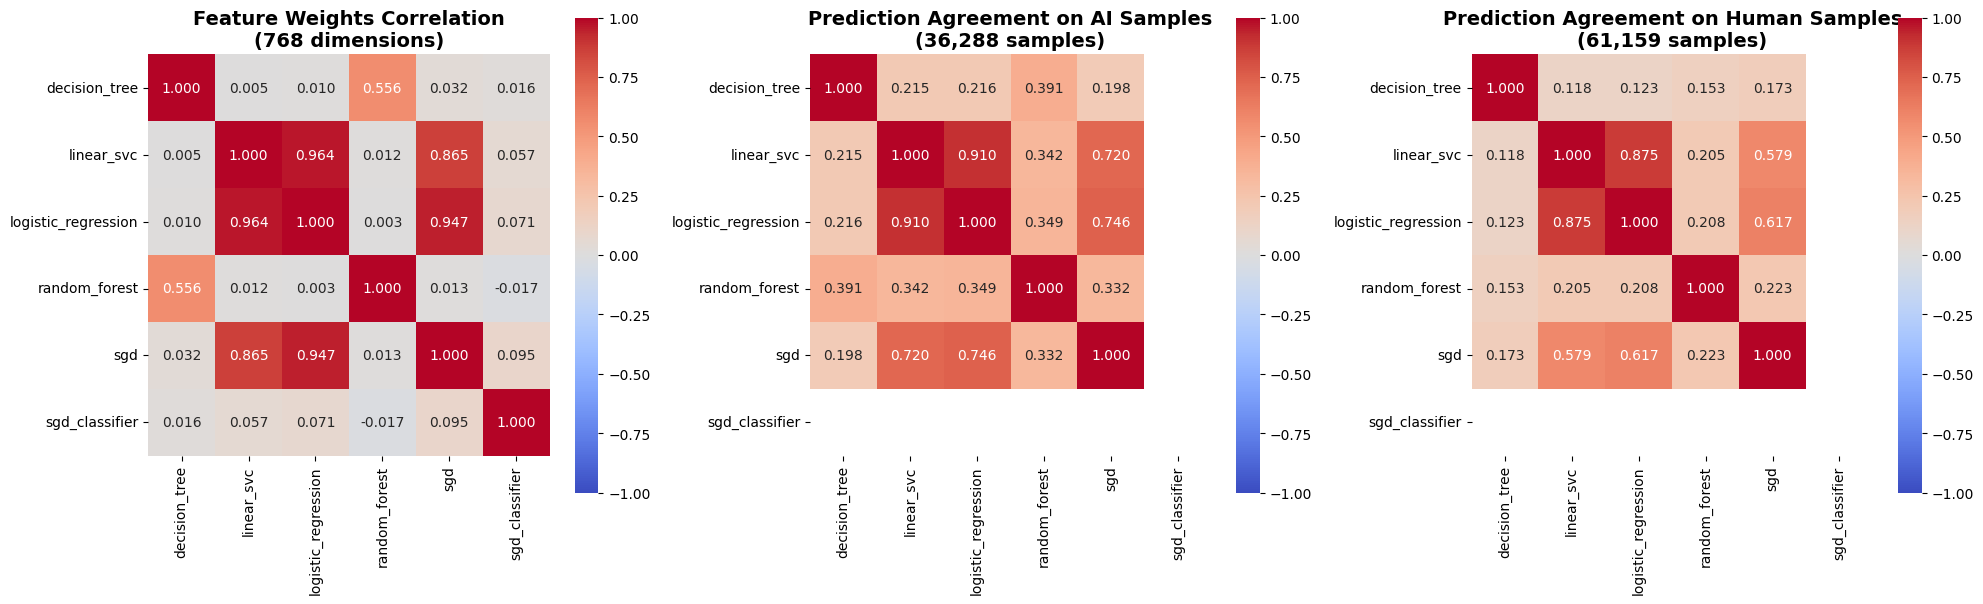


=== Summary ===

Feature-level mean correlation: 0.2418

Prediction-level mean correlation:
  AI samples: nan
  Human samples: nan

→ Models show MORE agreement on detecting Human-written text


In [8]:
# Visualize both analyses side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Column 1: Feature-level correlation
sns.heatmap(feature_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[0], square=True)
axes[0].set_title('Feature Weights Correlation\n(768 dimensions)', fontsize=14, fontweight='bold')

# Column 2: Prediction agreement on AI samples
sns.heatmap(ai_pred_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[1], square=True)
axes[1].set_title(f'Prediction Agreement on AI Samples\n({len(ai_samples_pred):,} samples)', 
                  fontsize=14, fontweight='bold')

# Column 3: Prediction agreement on Human samples
sns.heatmap(human_pred_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=axes[2], square=True)
axes[2].set_title(f'Prediction Agreement on Human Samples\n({len(human_samples_pred):,} samples)', 
                  fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/correlation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary
print("\n=== Summary ===")
print(f"\nFeature-level mean correlation: {feature_corr.values[np.triu_indices_from(feature_corr.values, k=1)].mean():.4f}")
print(f"\nPrediction-level mean correlation:")
print(f"  AI samples: {ai_pred_corr.values[np.triu_indices_from(ai_pred_corr.values, k=1)].mean():.4f}")
print(f"  Human samples: {human_pred_corr.values[np.triu_indices_from(human_pred_corr.values, k=1)].mean():.4f}")

if ai_pred_corr.values[np.triu_indices_from(ai_pred_corr.values, k=1)].mean() > human_pred_corr.values[np.triu_indices_from(human_pred_corr.values, k=1)].mean():
    print("\n→ Models show MORE agreement on detecting AI-generated text")
else:
    print("\n→ Models show MORE agreement on detecting Human-written text")


In [9]:
sample = "this is a human made piece of text. I have written it"
sample2 = """I’m trying to fetch some data from an API using async/await, but instead of getting the JSON object back, my function keeps returning a Promise.
Here’s my code:"""

print(predictor.forward(sample))
predictor.visualize_token_importance(sample)

[0]


In [10]:
predictor.get_token_importance_by_gradients(sample)[1].mean()

np.float32(-7.574184e-05)